# Buổi 8 — Notebook 4: Hệ thống gợi ý & So sánh mô hình

**Mục tiêu:**
1. So sánh KNN và Decision Tree trên cùng một bộ dữ liệu.
2. Xây dựng hàm gợi ý rượu vang (`src/recommender.py`).
3. Rút ra kết luận: mô hình nào phù hợp hơn cho bài toán thực tế?

**Hàm cần hoàn thiện:** `recommender.goi_y_ruou()`

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from src import preprocessing, knn as knn_mod, decision_tree as dt_mod, recommender

## 1. Huấn luyện lại cả hai mô hình

In [2]:
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
class_names   = wine.target_names

X_train, X_test, y_train, y_test = preprocessing.chia_train_test(X, y)
scaler, X_train_sc, X_test_sc    = preprocessing.chuan_hoa(X_train, X_test)

# --- KNN ---
K_TOT_NHAT  = 7    # thay bằng k bạn tìm được ở notebook 02
mo_hinh_knn = knn_mod.huan_luyen_knn(X_train_sc, y_train, k=K_TOT_NHAT)

# --- Decision Tree ---
DO_SAU_TOT  = 3    # thay bằng max_depth bạn tìm được ở notebook 03
mo_hinh_dt  = dt_mod.huan_luyen_cay(X_train, y_train, max_depth=DO_SAU_TOT)

print('Huấn luyện xong.')

Huấn luyện xong.


## 2. So sánh kết quả

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

do_cx_knn = accuracy_score(y_test, mo_hinh_knn.predict(X_test_sc))
do_cx_dt  = accuracy_score(y_test, mo_hinh_dt.predict(X_test))

X_all_sc  = StandardScaler().fit_transform(X)
cv_knn    = cross_val_score(KNeighborsClassifier(n_neighbors=K_TOT_NHAT),  X_all_sc, y, cv=5)
cv_dt     = cross_val_score(DecisionTreeClassifier(max_depth=DO_SAU_TOT, random_state=42), X, y, cv=5)

so_sanh = pd.DataFrame({
    'Mô hình'            : [f'KNN (k={K_TOT_NHAT})',   f'Decision Tree (depth={DO_SAU_TOT})'],
    'Độ cx test'         : [do_cx_knn,                  do_cx_dt],
    'CV trung bình'      : [cv_knn.mean(),               cv_dt.mean()],
    'CV độ lệch chuẩn'   : [cv_knn.std(),                cv_dt.std()],
    'Cần chuẩn hóa'      : ['Có',                        'Không'],
    'Giải thích được'    : ['Khó',                        'Có (vẽ cây)'],
}).set_index('Mô hình')

so_sanh.round(4)

,Độ cx test,CV trung bình,CV độ lệch chuẩn,Cần chuẩn hóa,Giải thích được
Mô hình,,,,,
KNN (k=7),1.0000,0.9665,0.0207,Có,Khó
Decision Tree (depth=3),0.9444,0.8710,0.0766,Không,Có (vẽ cây)


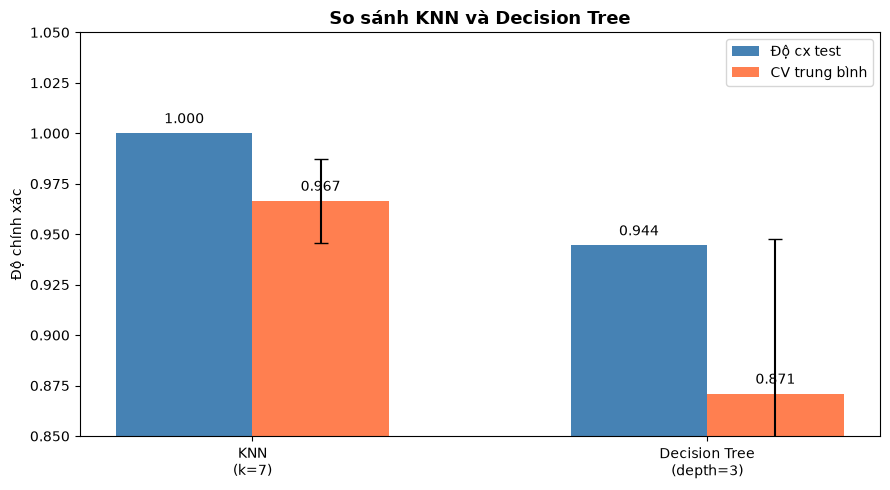

In [4]:
ten_mo_hinh = [f'KNN\n(k={K_TOT_NHAT})', f'Decision Tree\n(depth={DO_SAU_TOT})']
x = np.arange(2)
w = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [do_cx_knn, do_cx_dt], w, label='Độ cx test', color='steelblue')
b2 = ax.bar(x + w/2, [cv_knn.mean(), cv_dt.mean()], w,
            label='CV trung bình', color='coral',
            yerr=[cv_knn.std(), cv_dt.std()], capsize=5)
ax.set_ylabel('Độ chính xác')
ax.set_ylim(0.85, 1.05)
ax.set_title('So sánh KNN và Decision Tree', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ten_mo_hinh)
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Hệ thống gợi ý rượu vang

**Hàm cần hoàn thiện:** `recommender.goi_y_ruou()`

In [5]:
# Kiểm tra với hồ sơ trung bình của class_0
ho_so_class0 = (
    pd.DataFrame(X_train, columns=feature_names)[y_train == 0]
    .mean().to_dict()
)

print('=== Dự đoán bằng KNN ===')
print(recommender.goi_y_ruou(ho_so_class0, mo_hinh_knn, scaler, feature_names, class_names))

print('=== Dự đoán bằng Decision Tree ===')
print(recommender.goi_y_ruou(ho_so_class0, mo_hinh_dt, scaler, feature_names, class_names))

=== Dự đoán bằng KNN ===
Gợi ý: class_0  (độ tự tin: 100.0%)
=== Dự đoán bằng Decision Tree ===
Gợi ý: class_0  (độ tự tin: 100.0%)


## 4. Thử với hồ sơ của bạn

In [6]:
# Điền giá trị bất kỳ (trong khoảng hợp lý của dataset)
ruou_thu = {
    'alcohol': 13.5,
    'malic_acid': 2.0,
    'ash': 2.4,
    'alcalinity_of_ash': 20.0,
    'magnesium': 100.0,
    'total_phenols': 2.5,
    'flavanoids': 2.5,
    'nonflavanoid_phenols': 0.3,
    'proanthocyanins': 1.5,
    'color_intensity': 5.0,
    'hue': 1.0,
    'od280/od315_of_diluted_wines': 3.0,
    'proline': 900.0
}

print(recommender.goi_y_ruou(ruou_thu, mo_hinh_knn, scaler, feature_names, class_names))
print(recommender.goi_y_ruou(ruou_thu, mo_hinh_dt,  scaler, feature_names, class_names))

Gợi ý: class_0  (độ tự tin: 100.0%)
Gợi ý: class_0  (độ tự tin: 100.0%)


---
## Câu hỏi tổng kết

**1. Nếu bỏ qua EDA và không chuẩn hóa trước khi dùng KNN, điều gì có thể xảy ra?**

**Đáp án:** KNN sẽ bị dominated bởi `proline` (~747) vì khoảng cách Euclidean phụ thuộc tuyệt đối vào thang đo. Các đặc trưng như `nonflavanoid_phenols` (~0.36) hay `ash` (~2.4) gần như không đóng góp gì. Mô hình thực chất chỉ phân loại theo `proline` → accuracy giảm mạnh và không phản ánh đúng cấu trúc thực của dữ liệu. Không có EDA thì cũng không phát hiện được vấn đề này.

---

**2. Mô hình nào có CV độ lệch chuẩn thấp hơn? Điều đó nói lên điều gì về độ ổn định?**

**Đáp án:** **KNN** có CV std thấp hơn (0.0207 so với 0.0766 của DT). CV std phản ánh mức độ biến động của mô hình khi dữ liệu thay đổi (fold khác nhau). KNN ổn định hơn — accuracy không dao động nhiều giữa các lần chia khác nhau. DT có CV std cao hơn gần 4 lần → nhạy cảm hơn với cách chia train/test, dễ bị ảnh hưởng bởi nhiễu trong dữ liệu (variance cao).

---

**3. Bạn sẽ chọn mô hình nào để triển khai cho một cửa hàng rượu thực tế? Tại sao?**

**Đáp án:** **Decision Tree** phù hợp hơn cho cửa hàng thực tế vì:  
- **Giải thích được**: nhân viên bán hàng có thể hiểu quy tắc ("nếu color_intensity ≤ 3.82 và flavanoids > 1.575 thì đây là class_1"). Khách hàng hỏi "tại sao?" có thể được giải thích.  
- **Không cần chuẩn hóa**: dữ liệu thực tế từ thiết bị đo lường có thể đến ở các thang đo khác nhau — DT không quan tâm.  
- **Đủ chính xác**: 94.4% test accuracy và 87.1% CV mean vẫn là kết quả tốt cho ứng dụng gợi ý.  

Tuy nhiên nếu ưu tiên tuyệt đối về accuracy và không cần giải thích: KNN (96.65% CV mean) là lựa chọn tốt hơn.

---

**4. Nếu muốn cải thiện thêm, bạn sẽ thử những gì?**

**Đáp án:**  
- **GridSearchCV / RandomizedSearchCV**: tìm k (KNN) hoặc max_depth, min_samples_split (DT) tối ưu hơn.  
- **Random Forest**: ensemble nhiều Decision Tree → giảm variance, tổng quát hơn DT đơn, thường vượt trội cả KNN và DT.  
- **Feature selection**: loại bỏ đặc trưng tương quan cao (`total_phenols` khi đã có `flavanoids`) để giảm nhiễu cho KNN.  
- **PCA**: giảm chiều trước KNN, xử lý vấn đề đặc trưng tương quan.  
- **Thêm dữ liệu**: 178 mẫu còn ít — thu thập thêm sẽ giúp CV std giảm và đánh giá tin cậy hơn.

---
*Chạy `pytest tests/` để kiểm tra toàn bộ bài làm của bạn.*